# 04 — Market GGR Analysis
## Gaming Compliance & Risk Intelligence Platform

**Phase 7 deliverable.** Market performance and Gross Gaming Revenue (GGR) reporting
using **a synthetic monthly market series** across 48 synthetic months.

### Data source (synthetic)
A fabricated monthly market series generated by `data_raw/synthetic_data_generator.py`.
Series files: `data_raw/market_monthly_synthetic.csv` (totals) and
`data_raw/market_by_product_synthetic.csv` (by product category).

- **Cash Wagers** — total amounts wagered ($M)
- **NAGGR** — Non-Adjusted Gross Gaming Revenue ($M)
- **Active Player Accounts** — average monthly active accounts (thousands)
- **ARPPA** — Average Revenue Per Player Account ($)

All figures are real, as published by the market series (unaudited; excludes OLG and pari-mutuel
horse racing).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m = pd.read_csv("../data_raw/market_monthly_synthetic.csv")
m["Date"] = pd.to_datetime(m["YearMonth"] + "-01")
m["Fiscal_Year"] = m["FiscalYearQuarter"].str[:4]              # e.g. FY25
m = m.sort_values("Date").reset_index(drop=True)
print(f"{len(m)} months: {m.YearMonth.iloc[0]} -> {m.YearMonth.iloc[-1]}")
m.head()


48 months: 2022-04 -> 2026-03


,FiscalYearQuarter,YearMonth,CashWagers_M,NAGGR_M,ActiveAccounts_K,ARPPA,Date,Fiscal_Year
0,FY23Q1,2022-04,746,26.6,183,145,2022-04-01,FY23
1,FY23Q1,2022-05,770,30.9,204,151,2022-05-01,FY23
2,FY23Q1,2022-06,753,31.1,197,158,2022-06-01,FY23
3,FY23Q2,2022-07,686,26.2,199,132,2022-07-01,FY23
4,FY23Q2,2022-08,668,26.1,199,131,2022-08-01,FY23


## 1. Derived Metrics

In [2]:
m["Hold_Pct"] = 100 * m.NAGGR_M / m.CashWagers_M
m["GGR_YoY_Pct"] = m.NAGGR_M.pct_change(12) * 100      # vs same month last year
m["Active_Accounts"] = (m.ActiveAccounts_K * 1000).astype(int)
m[["YearMonth","CashWagers_M","NAGGR_M","Hold_Pct","ActiveAccounts_K","ARPPA","GGR_YoY_Pct"]].tail(6)


,YearMonth,CashWagers_M,NAGGR_M,Hold_Pct,ActiveAccounts_K,ARPPA,GGR_YoY_Pct
42,2025-10,1672,67.0,4.007177,455,147,10.743802
43,2025-11,1895,69.8,3.683377,468,149,6.079027
44,2025-12,1809,70.7,3.908237,469,151,5.838323
45,2026-01,2023,81.5,4.028670,488,167,2.002503
46,2026-02,2175,76.2,3.503448,491,155,4.814305
47,2026-03,2064,76.2,3.691860,472,161,-6.041924


## 2. Annual Summary by Fiscal Year (real)

In [3]:
fy = m.groupby("Fiscal_Year").agg(
    Months=("YearMonth","size"),
    Wagers_B=("CashWagers_M", lambda s: s.sum()/1000),
    GGR_B=("NAGGR_M", lambda s: s.sum()/1000),
    Avg_Active_K=("ActiveAccounts_K","mean")).reset_index()
fy["Hold_Pct"] = 100 * fy.GGR_B / fy.Wagers_B
fy["GGR_YoY_Pct"] = fy.GGR_B.pct_change() * 100
fy["Partial_Year"] = fy.Months != 12
fy.loc[fy.Partial_Year, "GGR_YoY_Pct"] = np.nan   # YoY not meaningful for partial years
disp = fy.copy()
disp["Fiscal_Year"] = disp.apply(lambda r: r.Fiscal_Year + " (partial)" if r.Partial_Year else r.Fiscal_Year, axis=1)
disp["Wagers_B"] = disp.Wagers_B.map(lambda x: f"${x:,.1f}B")
disp["GGR_B"] = disp.GGR_B.map(lambda x: f"${x:,.2f}B")
disp["Avg_Active_K"] = disp.Avg_Active_K.map(lambda x: f"{x:,.0f}K")
disp["Hold_Pct"] = disp.Hold_Pct.map(lambda x: f"{x:.2f}%")
disp["GGR_YoY_Pct"] = disp.GGR_YoY_Pct.map(lambda x: "" if pd.isna(x) else f"{x:+.0f}%")
disp


,Fiscal_Year,Months,Wagers_B,GGR_B,Avg_Active_K,Hold_Pct,GGR_YoY_Pct,Partial_Year
0,FY23,12,$9.4B,$0.37B,215K,3.96%,,False
1,FY24,12,$14.0B,$0.54B,292K,3.83%,+44%,False
2,FY25,12,$20.5B,$0.82B,370K,4.01%,+53%,False
3,FY26,12,$23.0B,$0.89B,448K,3.87%,+8%,False


## 3. Monthly Wagers & GGR (Apr 2022 → Apr 2026)

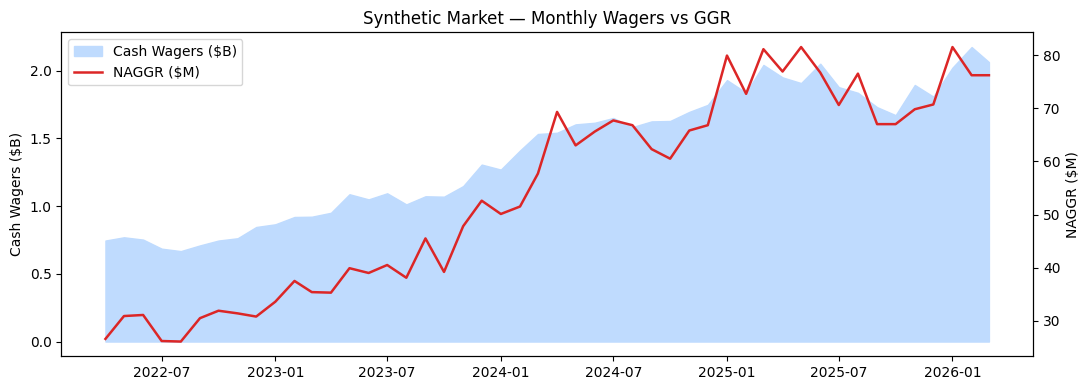

In [4]:
fig, ax1 = plt.subplots(figsize=(11,4))
ax1.fill_between(m.Date, m.CashWagers_M/1000, color="#bfdbfe", label="Cash Wagers ($B)")
ax1.set_ylabel("Cash Wagers ($B)")
ax2 = ax1.twinx()
ax2.plot(m.Date, m.NAGGR_M, color="#dc2626", lw=1.8, label="NAGGR ($M)")
ax2.set_ylabel("NAGGR ($M)")
ax1.set_title("Synthetic Market — Monthly Wagers vs GGR")
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels, loc="upper left")
plt.tight_layout(); plt.show()


## 4. Active Player Accounts & ARPPA

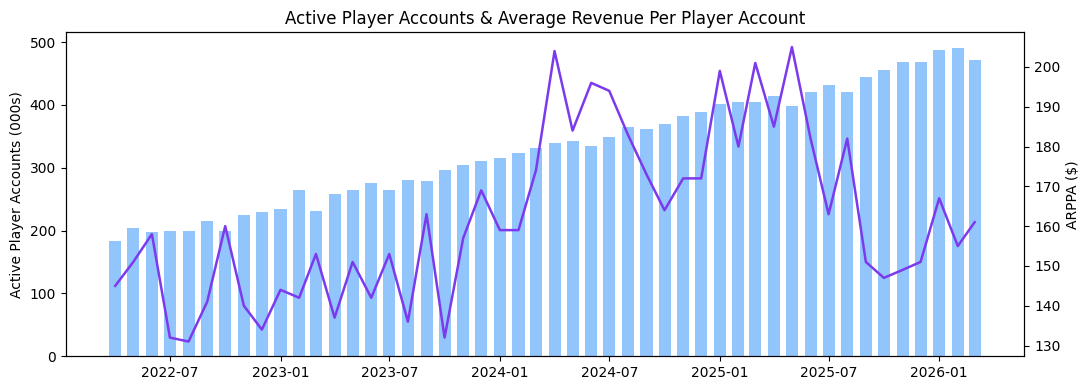

In [5]:
fig, ax1 = plt.subplots(figsize=(11,4))
ax1.bar(m.Date, m.ActiveAccounts_K, width=20, color="#93c5fd", label="Active Accounts (K)")
ax1.set_ylabel("Active Player Accounts (000s)")
ax2 = ax1.twinx()
ax2.plot(m.Date, m.ARPPA, color="#7c3aed", lw=1.8, label="ARPPA ($)")
ax2.set_ylabel("ARPPA ($)")
ax1.set_title("Active Player Accounts & Average Revenue Per Player Account")
plt.tight_layout(); plt.show()


## 5. Hold % Over Time

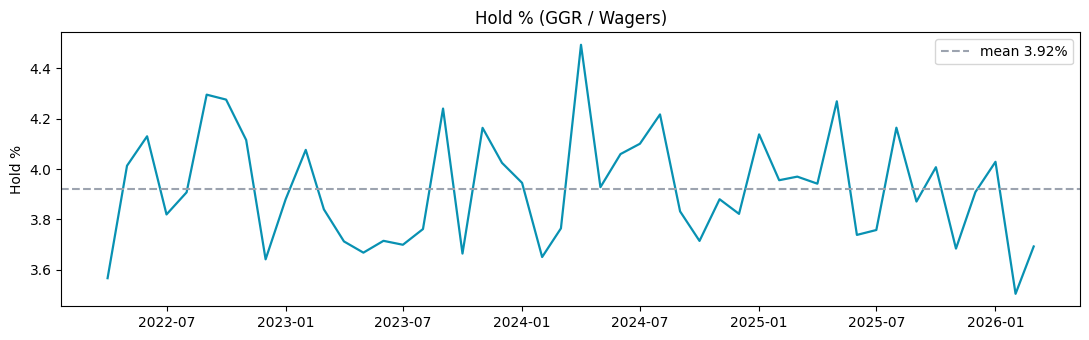

In [6]:
fig, ax = plt.subplots(figsize=(11,3.5))
ax.plot(m.Date, m.Hold_Pct, color="#0891b2", lw=1.6)
ax.axhline(m.Hold_Pct.mean(), color="#9ca3af", ls="--", label=f"mean {m.Hold_Pct.mean():.2f}%")
ax.set_title("Hold % (GGR / Wagers)"); ax.set_ylabel("Hold %"); ax.legend()
plt.tight_layout(); plt.show()


## 6. Product Category Mix (Casino / Betting / Poker)

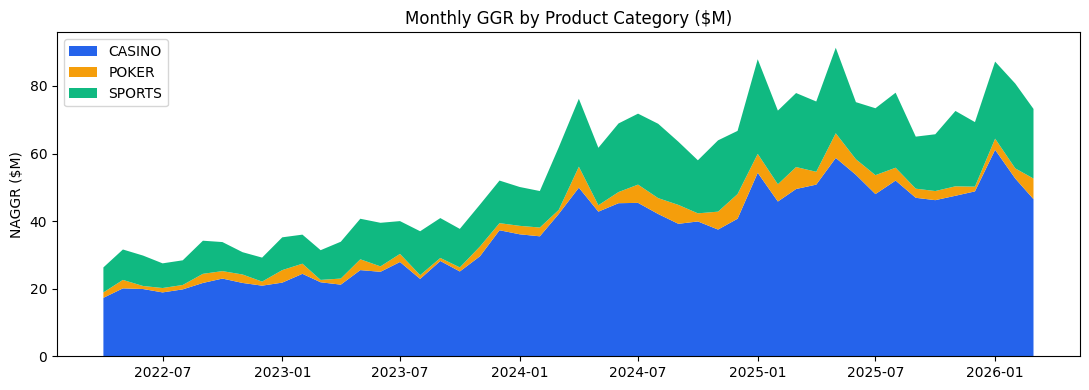

In [7]:
p = pd.read_csv("../data_raw/market_by_product_synthetic.csv")
p["Date"] = pd.to_datetime(p["YearMonth"] + "-01")
ggr = p.pivot_table(index="Date", columns="ProductCategory", values="NAGGR_M", aggfunc="sum").sort_index()
fig, ax = plt.subplots(figsize=(11,4))
ax.stackplot(ggr.index, [ggr[c] for c in ggr.columns], labels=list(ggr.columns),
             colors=["#2563eb","#f59e0b","#10b981"])
ax.set_title("Monthly GGR by Product Category ($M)"); ax.set_ylabel("NAGGR ($M)")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()


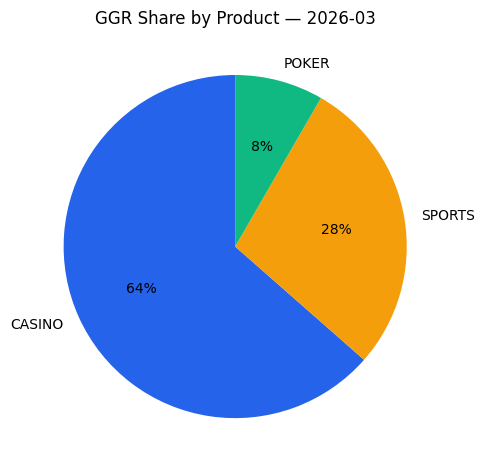

In [8]:
# Latest-month product share
latest = p[p.Date == p.Date.max()]
share = latest.set_index("ProductCategory")["NAGGR_M"]
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(share, labels=share.index, autopct="%1.0f%%",
       colors=["#2563eb","#f59e0b","#10b981"], startangle=90)
ax.set_title(f"GGR Share by Product — {latest.YearMonth.iloc[0]}")
plt.tight_layout(); plt.show()


## 7. Export for Dashboard

In [9]:
m_out = m[["YearMonth","Date","Fiscal_Year","FiscalYearQuarter","CashWagers_M","NAGGR_M",
           "Hold_Pct","Active_Accounts","ARPPA","GGR_YoY_Pct"]]
m_out.to_csv("../data_processed/market_performance_clean.csv", index=False)
fy.to_csv("../data_processed/market_performance_annual.csv", index=False)
print(f"Exported {len(m_out)} monthly rows + {len(fy)} fiscal-year rows to data_processed/")


Exported 48 monthly rows + 4 fiscal-year rows to data_processed/


## 8. Findings (synthetic data)

> These are generated, illustrative figures — they do not represent any real market.

- **Sustained growth across the series.** Monthly GGR rose from ~$27M to ~$76M over the
  48 synthetic months — roughly a **3x increase**.
- **Annual trajectory:** GGR grew each fiscal year (FY23 → FY26), with year-3 (FY25)
  reaching ~$0.82B on ~$20.5B wagered, up ~52% year-over-year.
- **Stable hold (~4%).** GGR/wagers holds in a tight band, showing consistent margin
  as volume scales — illustrating a maturing-market narrative.
- **Casino dominates** (~66% of GGR), with sports the second product and poker a small
  but steady share; seasonality is visible around major sports calendars.
- **Player base growth:** average monthly active accounts climb from ~180K to ~490K.

**Outputs:** `market_performance_clean.csv` (monthly), `market_performance_annual.csv`
(fiscal year). These feed the **Phase 8** Executive Overview and Market Performance dashboards.